# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias, imputar_info
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11375 entries, 0 to 11374
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11375 non-null  datetime64[ns]
 1   Ticker                       11375 non-null  object        
 2   Close                        11375 non-null  float64       
 3   Open                         11375 non-null  float64       
 4   Volume                       11375 non-null  float64       
 5   DateAdded                    6726 non-null   object        
 6   Sector                       11375 non-null  object        
 7   Industry                     11375 non-null  object        
 8   TotalRevenue                 11375 non-null  float64       
 9   GrossProfit                  10522 non-null  float64       
 10  OperatingIncome              11375 non-null  float64       
 11  NetIncome                    11375 non-nu

## Limpieza de Datos

Limpiar cadenas en Industry y Sector: 
* sin espacios iniciales ni finales.
* primer letra en mayúscula.
* se reemplaza el símbolo '&' por 'And'.

Además se convierten a variables de tipo "Category"

In [3]:
df = limpiar_industry_y_sector(df)

# Ver cambios
df[['Industry', 'Sector']].head()

,Industry,Sector
0,Grocery Stores,Consumer Defensive
1,Semiconductors,Technology
2,Software Infrastructure,Technology
3,Home Improvement Retail,Consumer Cyclical
4,Discount Stores,Consumer Defensive


In [4]:
# Valores únicos en Sector
df['Sector'].value_counts()

Sector
Consumer Cyclical         2330
Industrials               2223
Technology                1834
Healthcare                1140
Financial Services         901
Consumer Defensive         861
Basic Materials            614
Energy                     583
Communication Services     432
Real Estate                251
Utilities                  206
Name: count, dtype: int64

In [5]:
# Valores únicos en Industry
df['Industry'].value_counts()

Industry
Specialty Industrial Machinery           362
Semiconductors                           298
Software Application                     288
Engineering And Construction             263
Information Technology Services          253
                                        ... 
Reit Industrial                           23
Solar                                     22
Luxury Goods                              22
Utilities Independent Power Producers     22
Lumber And Wood Production                21
Name: count, Length: 116, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [6]:
df = columnas_en_millones(df)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [7]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df[(df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                            2149
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                   28.25313
Open                                   31.382216
Volume                                    7.3179
DateAdded                                   None
Sector                               Industrials
Industry                       Metal Fabrication
TotalRevenue                             171.258
GrossProfit                               39.919
OperatingIncome                           32.598
NetIncome                                 25.152
EBITDA                                       NaN
BasicAverageShares                        19.344
CashAndCashEquivalents                   89884.0
CurrentDebt                                  NaN
LongTermDebt                                 NaN
TotalDebt                                    NaN
StockholdersEquity                      302038.0
TotalAssets         

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [8]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df['TotalRevenue'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue  OperatingIncome
517    AVNT 2021-03-01     -30.20000       -12.700000
616     XPO 2021-03-01   -1093.00000        14.000000
750     ALB 2021-03-01   -1790.31392      -114.758843
2266    EMR 2021-12-01    -357.00000      -206.000000
2618   FTNT 2022-03-01   -1415.00000       213.700000
2780    BHF 2022-03-01    -150.00000      2266.000000
2911    XPO 2022-03-01   -2243.00000      -189.000000
4021      J 2022-12-01   -1258.70300       -69.426000
4494    CNA 2023-03-01   -3542.00000     -4648.000000
4782    BAX 2023-03-01    -704.00000      -285.000000
4819    BHF 2023-03-01    -127.00000        40.000000
4870     GE 2023-03-01  -12134.00000      4010.000000
4980    NGL 2023-06-01    -967.05000        65.932000
5816    WDC 2023-09-01   -3391.00000        93.000000
6267      J 2023-12-01   -1212.28200      -120.924000
6290   OTIS 2023-12-01   -3543.00000      -516.000000
6554   NDAQ 2024-03-01    -522.00000       481.000000
6585    DAN 2024-03-01    -4

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observa en 2 casos que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

#### Casos de deuda negativa: 
Se calcula el Pasivo Implícito, que surge de aplicar la ecuación contable fundamental `Activo` = `Pasivo` + `Patrimonio Neto`

In [9]:
# Caso 3:  Deuda negativa
condicion_3 = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)

# Calcular el Pasivo Implícito
df['PasivoImplicito'] = df['TotalAssets'] - df['StockholdersEquity']

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt', 'PasivoImplicito']
anomalias = df.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt  PasivoImplicito
3595    IEP 2022-09-01        NaN     -746.000      7134.000        15991.000
3991    IEP 2022-12-01        NaN     -745.000      7127.000        16908.000
6482   STLD 2024-03-01        NaN      459.987     -3286.537          171.287
7051   STLD 2024-06-01        NaN      425.696     -3570.028         -203.283
8437   STLD 2024-12-01        NaN      882.013     -3997.348         -218.698
8489    TXN 2025-03-01        NaN      750.000    -28049.000       -22289.000
Cantidad de casos: 6


* Se observa que la ecuación contable fundamental no se cumple. 

Se decide eliminar estos registros "tóxicos" del dataset.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos considerando la ecuación `EBITDA` = `OperatingIncome` + `DepreciationAndAmortization`, separando los registros según provengan de `yfinance` o de `simFin`:

In [10]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome', 'FinancialsSource']
anomalias = df.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
11111    GME 2026-06-01                         -0.3   144.9            144.9   

      FinancialsSource  
11111         yfinance  
Cantidad de casos: 1


* En este caso se observa que el valor implicito de `DepreciationAndAmortization` es igual a cero (EBITDA = OperatingIncome).
El valor de -0.3 pudo haberse tratado de un pequeño "ajuste contable", $300.000 dólares para una compañia del tamaño de `GameStop` es contablemente irrelevante. 

Se reemplazará el valor por cero.

In [11]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='simFin')

# Ver registros
anomalias = df.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
0        KR 2020-09-01                     -617.000     NaN          820.000   
3       LOW 2020-09-01                     -327.000     NaN         3957.000   
11       DY 2020-09-01                      -44.129     NaN           54.482   
13      TGT 2020-09-01                     -542.000     NaN         2300.000   
15      ADI 2020-09-01                     -107.077     NaN          450.954   
...     ...        ...                          ...     ...              ...   
9662    WGO 2025-09-01                       -5.500     NaN           30.200   
9686    HPE 2025-09-01                      -37.000     NaN          294.000   
9813   AVGO 2025-09-01                     -506.000     NaN         5915.000   
9877   ADBE 2025-09-01                      -41.000     NaN         2109.000   
9906   ORCL 2025-09-01                     -544.000     NaN         5191.000   

     FinancialsSource  
0              

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [12]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df)

# Se elimina la columna calculada 'PasivoImplicito'
df_clean = df_clean.drop(columns= 'PasivoImplicito')

## Tratamiento Inicial de Missings

In [13]:
# Ver incidencia de missings
mostrar_missings(df_clean)

TotalDebt                      0.836485
FreeCashFlow                   0.834638
EBITDA                         0.834638
DepreciationAndAmortization    0.464157
DateAdded                      0.408743
CurrentDebt                    0.236256
GrossProfit                    0.075029
LongTermDebt                   0.056381
TotalNoncurrentLiabilities     0.050664
CurrentAssets                  0.048377
CurrentLiabilities             0.048113
CapitalExpenditure             0.026915
BasicAverageShares             0.004134
CashAndCashEquivalents         0.003958
FinancingCashFlow              0.003254
OperatingCashFlow              0.002639
TotalRevenue                   0.002199
InvestingCashFlow              0.002199
StockholdersEquity             0.001671
TotalAssets                    0.001407
TotalLiabilities               0.001407
dtype: float64

In [14]:
sector_missing = df_clean.loc[df_clean['Sector'].isna(),['Date', 'Close', 'Ticker', 'Sector', 'Industry', 'FinancialsSource']]
print(sector_missing)
print("Cantidad de casos:", len(sector_missing))

Empty DataFrame
Columns: [Date, Close, Ticker, Sector, Industry, FinancialsSource]
Index: []
Cantidad de casos: 0


In [15]:
# Se imputan manualmente los casos encontrados
df_info_imputed = imputar_info(df_clean)

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [16]:
df_fin_imputed = imputar_equivalencias_financieras(df_info_imputed)
mostrar_missings(df_fin_imputed)

DateAdded                     0.408743
GrossProfit                   0.075029
LongTermDebt                  0.039229
TotalDebt                     0.039229
CurrentDebt                   0.039229
CapitalExpenditure            0.026915
FreeCashFlow                  0.025332
BasicAverageShares            0.004134
CashAndCashEquivalents        0.003958
FinancingCashFlow             0.003254
OperatingCashFlow             0.002639
TotalRevenue                  0.002199
InvestingCashFlow             0.002199
StockholdersEquity            0.001671
TotalAssets                   0.001407
CurrentAssets                 0.001407
TotalLiabilities              0.001407
CurrentLiabilities            0.001407
TotalNoncurrentLiabilities    0.001407
dtype: float64

In [17]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_num_imputed = imputar_numericas(df_fin_imputed)
mostrar_missings(df_num_imputed)

DateAdded                     0.408743
GrossProfit                   0.066321
LongTermDebt                  0.034128
CurrentDebt                   0.034128
TotalDebt                     0.034128
CapitalExpenditure            0.017328
FreeCashFlow                  0.017152
CashAndCashEquivalents        0.000880
TotalAssets                   0.000616
StockholdersEquity            0.000616
TotalLiabilities              0.000616
CurrentAssets                 0.000616
CurrentLiabilities            0.000616
TotalNoncurrentLiabilities    0.000616
FinancingCashFlow             0.000528
OperatingCashFlow             0.000528
InvestingCashFlow             0.000528
BasicAverageShares            0.000440
dtype: float64

Se remueven los Missings remanentes en columnas numéricas relevantes, es decir excluyendo las siguientes columnas que no se utilizan en el pipeline actual:
- `GrossProfit`
- `FinancingCashFlow`
- `InvestingCashFlow`

Es necesario que no hayan valores perdidos antes de calcular los valores TTM. 

In [18]:
cols_no_relevantes = ['GrossProfit', 'FinancingCashFlow', 'InvestingCashFlow']
df_imputed = quitar_nulos_relevantes(df_num_imputed, cols_no_relevantes)
mostrar_missings(df_imputed)

DateAdded      0.409833
GrossProfit    0.055380
dtype: float64

In [19]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 1 to 11368
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         10780 non-null  datetime64[ns]
 1   Ticker                       10780 non-null  object        
 2   Close                        10780 non-null  float64       
 3   Open                         10780 non-null  float64       
 4   Volume                       10780 non-null  float64       
 5   DateAdded                    6362 non-null   object        
 6   Sector                       10780 non-null  category      
 7   Industry                     10780 non-null  category      
 8   TotalRevenue                 10780 non-null  float64       
 9   GrossProfit                  10183 non-null  float64       
 10  OperatingIncome              10780 non-null  float64       
 11  NetIncome                    10780 non-null  f

## Feature Engineering

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres):

In [20]:
df_with_ttm = transformar_flujos_a_ttm(df_imputed)
mostrar_missings(df_with_ttm)

DateAdded          0.409833
GrossProfit_TTM    0.052412
dtype: float64

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [21]:
df_with_years_since_added = crear_years_since_added(df_with_ttm)

* Calcular métricas financieras y ratios de valuación:

In [22]:
df_with_metrics = calcular_metricas(df_with_years_since_added)
mostrar_missings(df_with_metrics)

DebtToEquity       0.068182
GrossProfit_TTM    0.052412
ReturnOnEquity     0.003618
dtype: float64

Convertir `volume`:
* Se reemplaza el volumen total trimestral por su promedio diario (AverageDailyVolume), ya que es el valor estándar utilizado en finanzas. El cálculo es aproximado, dividiendo los valores de `Volume` entre 63 (252 días hábiles entre 4).
* Se aplica lag de 1 período a AverageDailyVolume para evitar Data Leakage.

In [23]:
df_volume_converted = convertir_volumen_a_adv(df_with_metrics)
columnas_lag1 = ['AverageDailyVolume']
df_volume_converted = calcular_lag(df_volume_converted, columnas_lag1, q=1)

Cálculo de los crecimientos y las aceleraciones:
* Primero se calculan las tasas de crecimiento para las variables indicadas en "crecimiento_cols", incluyendo las variaciones anuales (YoY) y trimestrales (QoQ) .
* Luego se calculan las aceleraciones (Momento - Tendencia), definidas como la diferencia entre la tasa de cambio de corto plazo (QoQ) y la de largo plazo (YoY). 

In [24]:
# Calcular crecimientos
crecimiento_cols = [
    'TotalRevenue_TTM',
    'EBITDA_TTM',
    'FreeCashFlow_TTM',
    'CapitalExpenditure_TTM',
    'AverageDailyVolume_Lag1'
]
df_with_growth = calcular_crecimientos(df_volume_converted, crecimiento_cols)
mostrar_missings(df_with_growth)

CapitalExpenditure_TTM_YoY     0.187384
AverageDailyVolume_Lag1_YoY    0.187199
FreeCashFlow_TTM_YoY           0.187106
EBITDA_TTM_YoY                 0.187106
TotalRevenue_TTM_YoY           0.187106
DebtToEquity                   0.068182
GrossProfit_TTM                0.052412
CapitalExpenditure_TTM_QoQ     0.047124
AverageDailyVolume_Lag1_QoQ    0.046939
TotalRevenue_TTM_QoQ           0.046846
FreeCashFlow_TTM_QoQ           0.046846
EBITDA_TTM_QoQ                 0.046846
ReturnOnEquity                 0.003618
AverageDailyVolume_Lag1        0.000093
dtype: float64

Antes de calcular las aceleraciones, se tratan los valores nulos en los valores iniciales de las columnas de crecimiento. Se imputan con las tasas de inflación promedio históricas de EE.UU. (asumiendo crecimiento neutral) y se crean variables flag `IsMissing`: 

In [25]:
df_growth_imputed = imputar_crecimientos(df_with_growth, crecimiento_cols)
mostrar_missings(df_growth_imputed)

DebtToEquity               0.068182
GrossProfit_TTM            0.052412
ReturnOnEquity             0.003618
AverageDailyVolume_Lag1    0.000093
dtype: float64

* Se calculan las aceleraciones, definidas como la tasa de crecimiento de corto plazo (QoQ) menos la de largo (YoY):

In [26]:
df_with_acc = calcular_aceleraciones(df_growth_imputed, crecimiento_cols)

* Se calculan los retornos trimestrales, completando missings con cero (valor neutral). Luego se calculan la varianza del activo y la covarianza con el mercado para obtener el coeficiente Beta de corto plazo (ShortTermBeta):

In [ ]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")

df_with_returns = calcular_retornos_y_betas(df_with_acc, df_index)
mostrar_missings(df_with_returns)

* Se calculan tamaños relativos: RelativeAssets y RelativeRevenue

In [29]:
df_with_features = calcular_relative_size(df_with_returns)
mostrar_missings(df_with_features)

DebtToEquity               0.068182
GrossProfit_TTM            0.052412
ReturnOnEquity             0.003618
ShortTermBeta              0.001670
AverageDailyVolume_Lag1    0.000093
dtype: float64

## Tratamiento Final de Missings

* Se aplica la imputación por medias móviles para las métricas calculadas:

In [30]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_final_num_imputed = imputar_numericas(df_with_features)
mostrar_missings(df_final_num_imputed)

DebtToEquity               0.057143
GrossProfit_TTM            0.050278
ShortTermBeta              0.001670
ReturnOnEquity             0.000835
AverageDailyVolume_Lag1    0.000093
dtype: float64

* Se eliminan missings remanentes:

In [31]:
cols_no_relevantes = [
    'GrossProfit_TTM',
    ]
df_final_imputed = quitar_nulos_relevantes(df_final_num_imputed, cols_no_relevantes)
df_final_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10146 entries, 1 to 10779
Data columns (total 74 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   10146 non-null  datetime64[ns]
 1   Ticker                                 10146 non-null  object        
 2   Close                                  10146 non-null  float64       
 3   Open                                   10146 non-null  float64       
 4   Sector                                 10146 non-null  category      
 5   Industry                               10146 non-null  category      
 6   CashAndCashEquivalents                 10146 non-null  float64       
 7   CurrentDebt                            10146 non-null  float64       
 8   LongTermDebt                           10146 non-null  float64       
 9   TotalDebt                              10146 non-null  float64    

## Análisis Exploratorio de Datos

In [33]:
# Distribución de variables contínuas
df_final_imputed.describe().round(4)

,Date,Close,Open,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,CurrentAssets,...,AverageDailyVolume_Lag1_YoY_IsMissing,TotalRevenue_TTM_Acceleration,EBITDA_TTM_Acceleration,FreeCashFlow_TTM_Acceleration,CapitalExpenditure_TTM_Acceleration,AverageDailyVolume_Lag1_Acceleration,QuarterlyReturn_Lag1,ShortTermBeta,RelativeAssets,RelativeRevenue
count,10146,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,1.014600e+04,10146.0000,1.014600e+04,10146.0000,...,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000,10146.0000
mean,2023-09-01 20:28:06.102897664,1145.1460,1109.1067,4158.6218,2493.5821,10547.4942,1.316364e+04,14308.1135,4.423587e+04,14967.8255,...,0.1870,-0.0756,-0.2811,-0.2405,0.1648,-0.0669,0.0338,0.8312,0.0022,0.0022
min,2020-12-01 00:00:00,0.5700,0.5300,0.1685,0.0000,0.0000,2.950000e-01,-9658.0000,1.346560e+01,2.0036,...,0.0000,-10.0028,-10.3417,-10.8519,-10.9742,-10.4500,-0.8019,-24.3611,0.0000,0.0000
25%,2022-03-01 00:00:00,41.4650,40.7305,329.0000,68.0070,1495.1225,1.823180e+03,2068.2185,6.842651e+03,2149.3250,...,0.0000,-0.0959,-0.2847,-0.3487,-0.0926,-0.2472,-0.0535,-0.0366,0.0003,0.0004
50%,2023-09-01 00:00:00,83.1682,81.9826,898.7500,399.5000,3828.4455,4.517500e+03,4929.9000,1.524460e+04,4277.4445,...,0.0000,-0.0339,-0.0584,-0.0226,0.0314,-0.0277,0.0000,0.5200,0.0008,0.0008
75%,2025-03-01 00:00:00,164.8541,161.2185,2802.5000,1189.8000,10312.7500,1.194150e+04,12727.0000,3.933350e+04,11888.7752,...,0.0000,0.0062,0.0810,0.2066,0.2491,0.1493,0.1103,1.7584,0.0020,0.0017
max,2026-06-01 00:00:00,775000.0000,775648.0000,546164.0000,893418.0000,491192.0000,1.187451e+06,656742.0000,1.766181e+06,847603.3833,...,1.0000,3.5477,10.8489,10.9256,10.7500,10.2727,5.1099,33.1118,0.0799,0.0615
std,NaN,24204.8372,23410.3364,16373.8710,23580.9242,22893.2065,4.181532e+04,35893.9988,1.047799e+05,44308.0837,...,0.3899,0.3721,1.6918,2.1910,1.2845,1.5652,0.1734,1.9564,0.0052,0.0048


In [ ]:
# Describe de una columna específica
df_final_imputed['ShortTermBeta'].describe().round(4).T

count    1.014600e+04
mean     8.680392e+04
std      2.892123e+05
min     -2.368220e+03
25%      8.985800e+03
50%      2.228547e+04
75%      6.349872e+04
max      5.245826e+06
Name: EnterpriseValue, dtype: float64

In [35]:
# Coeficientes de asimetría
df_final_imputed.select_dtypes(include="number").skew().sort_values(ascending=False)

BookToMarket                     98.323067
NetDebtToEbitda                  58.242081
FcfToEbitda                      54.270958
EarningsYield                    48.285982
CapExToRevenue                   41.339117
                                   ...    
CapitalExpenditure_TTM          -11.721700
TotalRevenue_TTM_Acceleration   -18.116683
ReturnOnEquity                  -27.377436
OperatingMargins                -39.209205
ProfitMargins                   -39.411618
Length: 69, dtype: float64

In [36]:
# Analizar extremos
df_min = df_final_imputed.loc[df_final_imputed['ShortTermBeta'].idxmin()]
df_min

Date                                    2021-09-01 00:00:00
Ticker                                                  GME
Close                                             49.052502
Open                                                   56.0
Sector                                    Consumer Cyclical
                                               ...         
AverageDailyVolume_Lag1_Acceleration                -0.7055
QuarterlyReturn_Lag1                               1.233403
ShortTermBeta                                    -24.361093
RelativeAssets                                     0.000132
RelativeRevenue                                     0.00051
Name: 4164, Length: 74, dtype: object

Cont


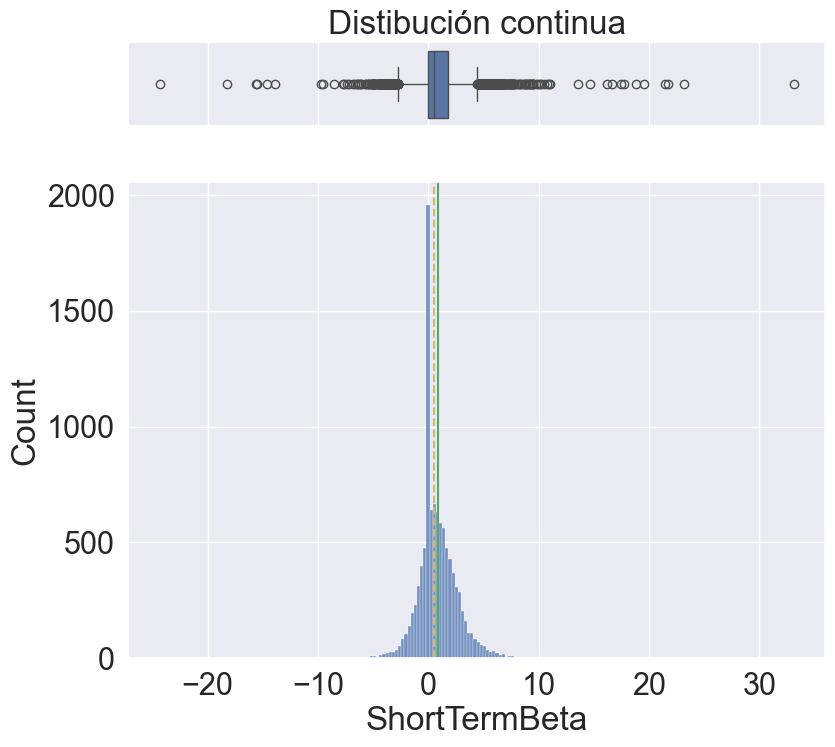

In [37]:
# Graficar
columna_a_graficar = 'ShortTermBeta' # indicar columna para el gráfico
plot(df_final_imputed[columna_a_graficar])

## Transformaciones

* Transformaciones logarítmicas:

In [ ]:
columnas_log = [ 
    'CapExToRevenue',
    'DebtToEquity',
    'MarketCap'
    ]

df_log_transformed = transformar_log(
    df_final_imputed, 
    columnas_log, 
    calculo_1p=True
    )

print("--- Coeficientes de asimetría antes y después de transformar: ---\n")
for col in columnas_log:
    print(f'{col}:', df_final_imputed[col].skew(), '-.', df_log_transformed[f'{col}_Log1p'].skew())

CapExToRevenue: 41.33911748106051 - 16.58628434514137
DebtToEquity: 37.652781424913606 - 2.6679174328074096
MarketCap: 9.196017617125197 - -0.03152328869683105


* Transformaciones Yeo-Johnson (trata columnas que puedan tener valores negativos):

In [ ]:
columnas_yeo = [ 
    'EnterpriseValue',
    ]

df_transformed = transformar_yeo_johnson(
    df_log_transformed, 
    columnas_yeo
    )

print("--- Coeficientes de asimetría antes y después de transformar: ---\n")
for col in columnas_yeo:
    print(f'{col}:', df_final_imputed[col].skew(), '->', df_transformed[f'{col}_YeoTransformed'].skew())

Coeficientes de asimetría antes y después de transformar:

EnterpriseValue: 8.984103135893218 - 2.228748985805067


## Tratamiento de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [40]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'EarningsYield',
    'EbitdaYield',
    'BookToMarket',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

In [41]:
df_transformed_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10146 entries, 1 to 10779
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   Sector                                 10146 non-null  category
 1   Industry                               10146 non-null  category
 2   FinancialsSource                       10146 non-null  object  
 3   YearsSinceAdded                        10146 non-null  float64 
 4   OperatingMargins                       10146 non-null  float64 
 5   ProfitMargins                          10146 non-null  float64 
 6   ReturnOnAssets                         10146 non-null  float64 
 7   ReturnOnEquity                         10146 non-null  float64 
 8   CurrentRatio                           10146 non-null  float64 
 9   NetDebtToEbitda                        10146 non-null  float64 
 10  FcfToEbitda                            10146 non-null  float64 

In [42]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [43]:
# Coeficientes de asimetría luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

FreeCashFlow_TTM_QoQ_IsMissing           4.376942
EBITDA_TTM_QoQ_IsMissing                 4.376942
TotalRevenue_TTM_QoQ_IsMissing           4.376942
AverageDailyVolume_Lag1_QoQ_IsMissing    4.371460
CapitalExpenditure_TTM_QoQ_IsMissing     4.360547
RelativeAssets                           1.737242
AverageDailyVolume_Lag1                  1.729091
RelativeRevenue                          1.671651
CapExToRevenue_Log1p                     1.626868
FreeCashFlow_TTM_YoY_IsMissing           1.606813
EBITDA_TTM_YoY_IsMissing                 1.606813
TotalRevenue_TTM_YoY_IsMissing           1.606813
AverageDailyVolume_Lag1_YoY_IsMissing    1.605981
CapitalExpenditure_TTM_YoY_IsMissing     1.604319
DebtToEquity_Log1p                       1.559748
CurrentRatio                             1.533515
EnterpriseValue_YeoTransformed           1.441552
YearsSinceAdded                          1.419927
AverageDailyVolume_Lag1_YoY              1.075682
AverageDailyVolume_Lag1_QoQ              1.022983


Cont


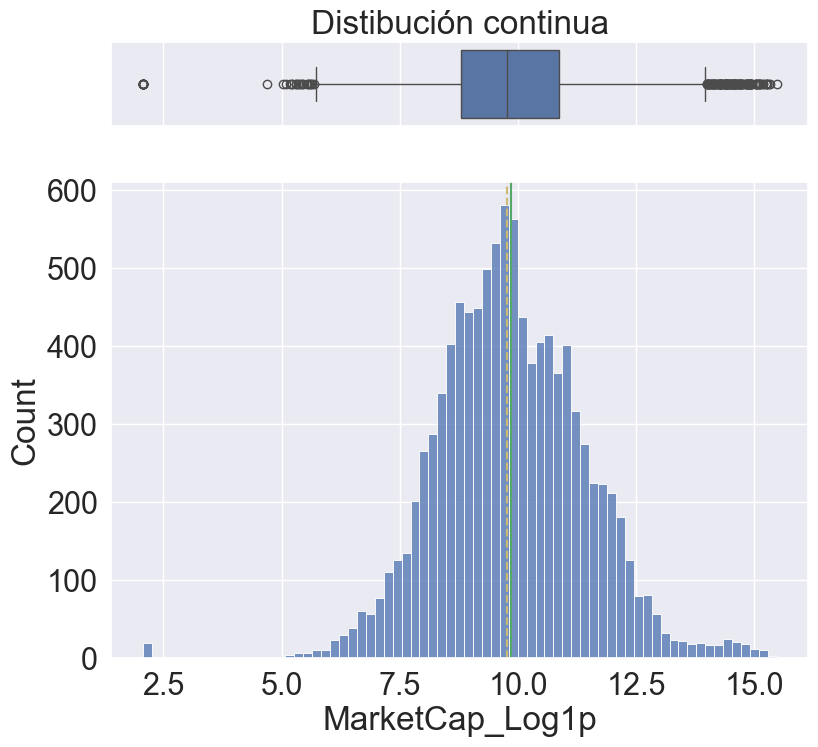

In [44]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [45]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,10146.0,15.263256,20.227430,0.000000e+00,0.000000,7.000000,24.000000,69.000000
OperatingMargins,10146.0,0.144417,0.131109,-3.696910e-01,0.063186,0.127022,0.206462,0.636588
ProfitMargins,10146.0,0.095795,0.118040,-3.079690e-01,0.034004,0.083927,0.147471,0.488477
ReturnOnAssets,10146.0,0.064496,0.071940,-1.855690e-01,0.026960,0.056513,0.097268,0.308656
ReturnOnEquity,10146.0,0.195910,0.263418,-5.539790e-01,0.077624,0.157355,0.286262,0.913651
CurrentRatio,10146.0,1.713424,0.960816,1.314860e-01,1.077111,1.449480,2.100816,5.173209
NetDebtToEbitda,10146.0,2.988494,5.879424,-1.250496e+01,0.492010,2.178573,4.821182,17.844383
FcfToEbitda,10146.0,0.757137,1.002170,-1.722131e+00,0.403867,0.748515,1.107727,3.220280
AverageDailyVolume_Lag1,10146.0,3.292374,3.949856,3.174603e-06,0.709563,1.621434,4.125961,14.388406
TotalRevenue_TTM_YoY,10146.0,0.072099,0.136733,-3.131793e-01,0.013653,0.035709,0.122214,0.448227


## Concatenación Final y Almacenamiento

In [46]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10146 entries, 1 to 10779
Data columns (total 74 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 10146 non-null  float64       
 1   CurrentDebt                            10146 non-null  float64       
 2   LongTermDebt                           10146 non-null  float64       
 3   TotalDebt                              10146 non-null  float64       
 4   StockholdersEquity                     10146 non-null  float64       
 5   TotalAssets                            10146 non-null  float64       
 6   CurrentAssets                          10146 non-null  float64       
 7   CurrentLiabilities                     10146 non-null  float64       
 8   TotalNoncurrentLiabilities             10146 non-null  float64       
 9   TotalLiabilities                       10146 non-null  float64    

In [47]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
